# Case Study: PCA to Study the Dimensionality of Quality of Life in Cities





## Study Objective

This notebook studies quality-of-life patterns across 329 cities using Principal Component Analysis (PCA).

From a methodological perspective, the objective is to transform 9 observed variables into a smaller set of components that are easier to interpret, while retaining most of the original information (variance).


### Imports





In [161]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
from datetime import datetime

# libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

from scipy.stats import chi2
from sklearn.decomposition import PCA

import time
import math

warnings.filterwarnings("ignore")



### Functions





In [162]:
def plot_numeric_distributions(df, cols=None, bins=30):

    # Select only numeric columns if no list is provided
    if cols is None:
        cols = df.select_dtypes(include=np.number).columns.tolist()

    # General style configuration
    sns.set(style="whitegrid")

    for col in cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f"Distribution of '{col}'", fontsize=14, fontweight='bold')

        # Boxplot
        sns.boxplot(y=df[col], ax=axes[0], color="skyblue")
        axes[0].set_title("Boxplot", fontsize=12)
        axes[0].set_xlabel("")
        axes[0].set_ylabel(col)

        # Histogram
        sns.histplot(df[col], bins=bins, kde=True, color="salmon", ax=axes[1])
        axes[1].set_title("Histogram", fontsize=12)
        axes[1].set_xlabel(col)
        axes[1].set_ylabel("Frequency")

        plt.tight_layout()
        plt.show()



## Development





### 1. Data Preparation

In this section, the notebook performs three essential preprocessing steps:

1. It loads the dataset and validates the expected structure (column count and column names).
2. It sets `City` as the index so each observation remains identifiable throughout the analysis.
3. It prepares variables for consistent interpretation.

A key conceptual point: Housing and Crime have opposite meaning relative to the other indicators (higher values indicate worse conditions). Reversing their sign aligns directionality so that higher values consistently represent better quality-of-life conditions. This improves interpretability of loadings and component scores.


In [163]:
# Load data into a pandas DataFrame
data = pd.read_csv("dataset.csv")

expected_columns = [
    "City",
    "Climate and Terrain",
    "Housing",
    "Health Care and Environment",
    "Crime",
    "Transportation",
    "Education",
    "Arts",
    "Recreation",
    "Economy",
]

if len(data.columns) != len(expected_columns):
    raise ValueError(f"Unexpected number of columns: {len(data.columns)}")

data.columns = expected_columns
data = data.set_index("City")
data.head()


,Climate and Terrain,Housing,Health Care and Environment,Crime,Transportation,Education,Arts,Recreation,Economy
City,,,,,,,,,
"Abilene,TX",521,6200,237,923,4031,2757,996,1405,7633
"Akron,OH",575,8138,1656,886,4883,2438,5564,2632,4350
"Albany,GA",468,7339,618,970,2531,2560,237,859,5250
"Albany-Schenectady-Troy,NY",476,7908,1431,610,6883,3399,4655,1617,5864
"Albuquerque,NM",659,8393,1853,1483,6558,3026,4496,2612,5727


In [164]:
data.info()

<class 'pandas.DataFrame'>
Index: 329 entries, Abilene,TX to Yuba-City,CA
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Climate and Terrain          329 non-null    int64
 1   Housing                      329 non-null    int64
 2   Health Care and Environment  329 non-null    int64
 3   Crime                        329 non-null    int64
 4   Transportation               329 non-null    int64
 5   Education                    329 non-null    int64
 6   Arts                         329 non-null    int64
 7   Recreation                   329 non-null    int64
 8   Economy                      329 non-null    int64
dtypes: int64(9)
memory usage: 25.7+ KB


In [165]:
df = data.copy()

### 2. Descriptive Analysis of the Variables

This section establishes statistical context before PCA.

The notebook combines summary statistics, univariate plots, and correlation analysis to understand:
- scale and spread,
- distribution shape,
- potential extreme observations,
- dependence structure between variables.

With 9 variables, a full pairwise visual inspection would require **36** scatter plots (`9*8/2`), which motivates dimensionality reduction.


##### Summary Statistics





In [166]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Climate and Terrain,329.0,538.732523,120.808259,105.0,480.0,542.0,592.0,910.0
Housing,329.0,8346.559271,2385.262622,5159.0,6760.0,7877.0,9015.0,23640.0
Health Care and Environment,329.0,1185.738602,1003.002036,43.0,583.0,833.0,1445.0,7850.0
Crime,329.0,961.054711,357.154186,308.0,707.0,947.0,1156.0,2498.0
Transportation,329.0,4210.082067,1451.179240,1145.0,3141.0,4080.0,5205.0,8625.0
Education,329.0,2814.887538,320.792953,1701.0,2619.0,2794.0,3012.0,3781.0
Arts,329.0,3150.884498,4642.283738,52.0,778.0,1871.0,3844.0,56745.0
Recreation,329.0,1845.957447,807.888171,300.0,1316.0,1670.0,2176.0,4800.0
Economy,329.0,5525.364742,1084.468523,3045.0,4842.0,5384.0,6113.0,9980.0


All variables contain 329 observations, indicating there are no missing values. This is important because PCA requires a complete numeric matrix unless imputation is applied beforehand.


Housing and Arts show high dispersion, with large gaps between upper quartiles and maximum values. From a reviewer perspective, this suggests heterogeneous city profiles and possible influential observations.

At this stage, retaining these values is methodologically reasonable because there is no evidence they are data errors.


In [167]:
# Check for duplicate rows
print("\nNumber of duplicate rows:\n")
print(df.duplicated().sum())


Number of duplicate rows:

0


#### Univariate Analysis





In [168]:
num_columns = df.columns.to_list()
num_columns

['Climate and Terrain',
 'Housing',
 'Health Care and Environment',
 'Crime',
 'Transportation',
 'Education',
 'Arts',
 'Recreation',
 'Economy']

Boxplots and histograms are used together because they answer complementary questions:
- boxplots highlight spread, median, and potential outliers,
- histograms reveal distribution shape (symmetry, skewness, concentration).


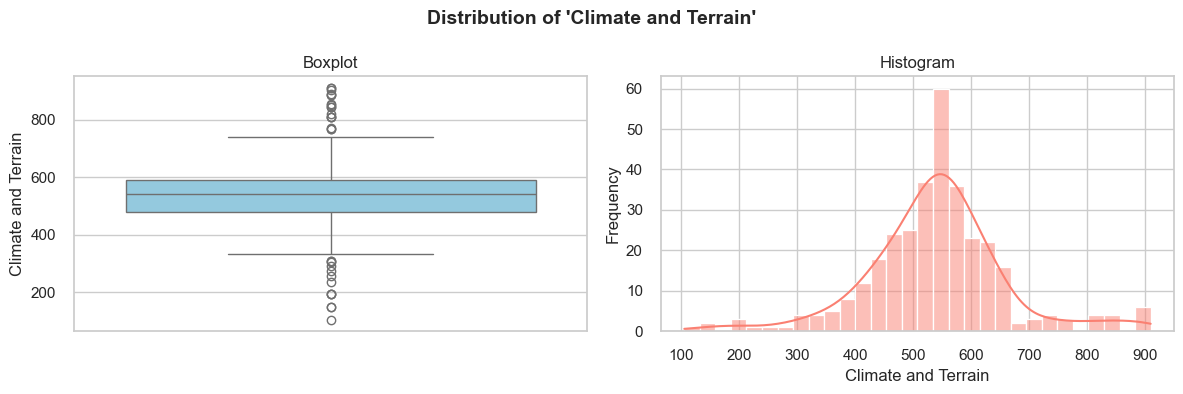

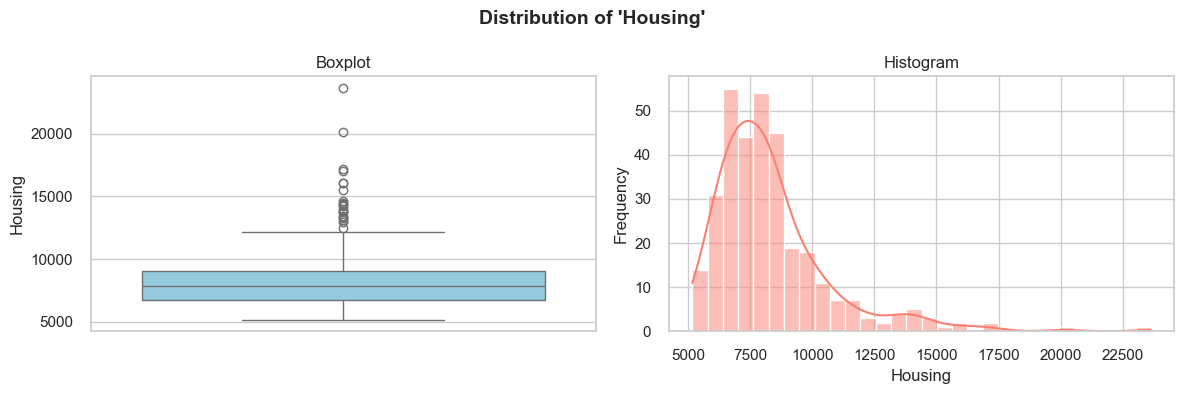

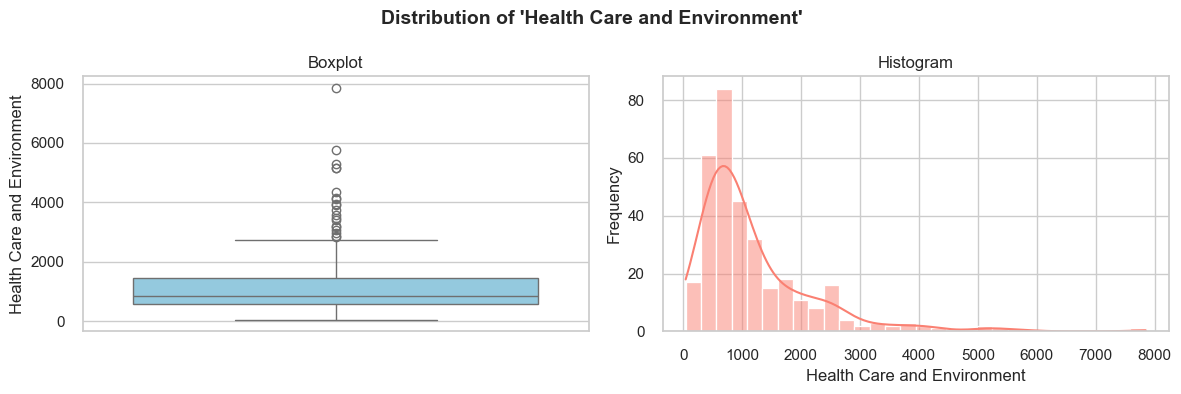

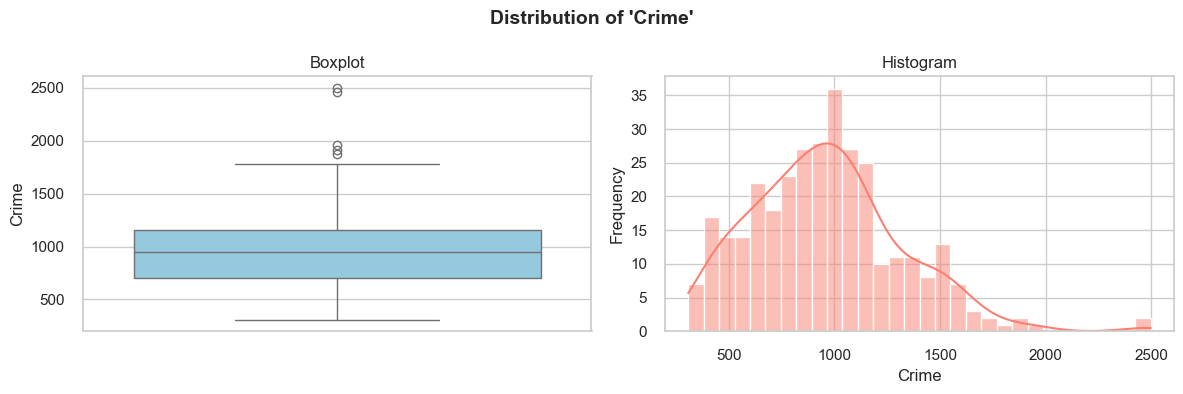

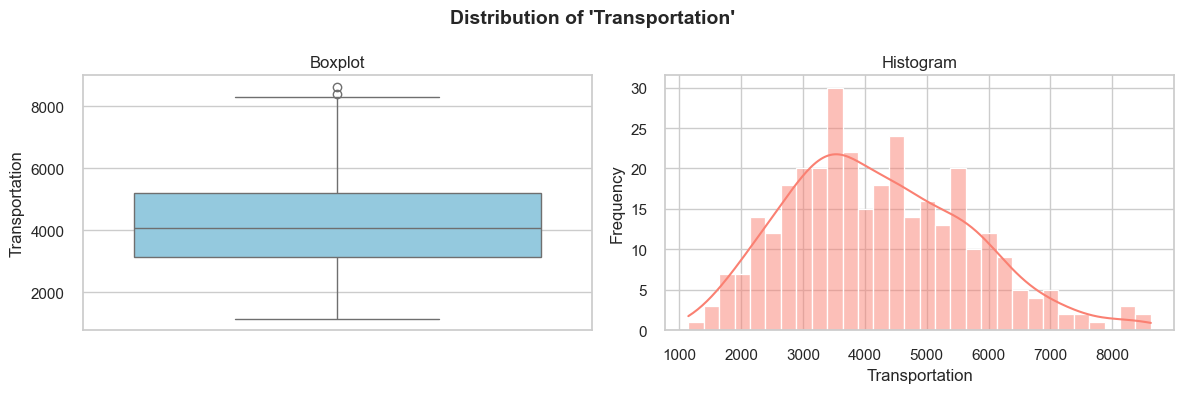

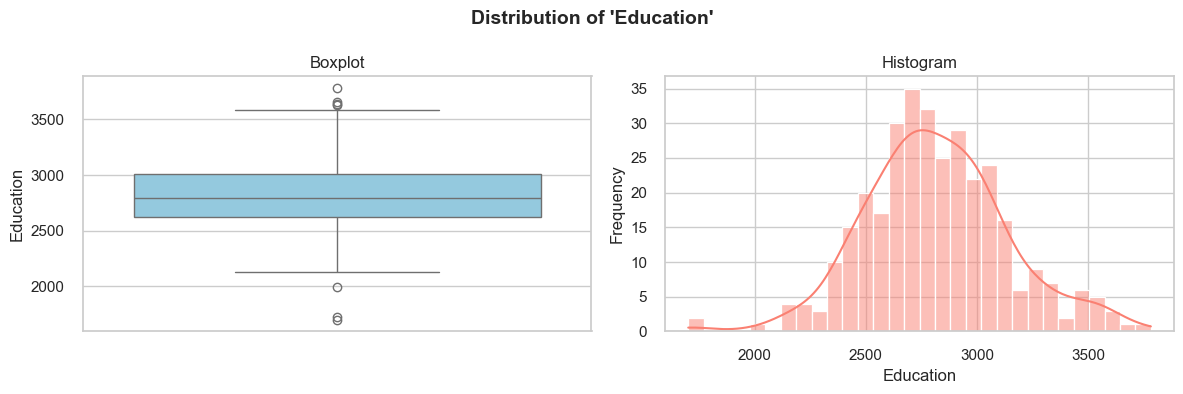

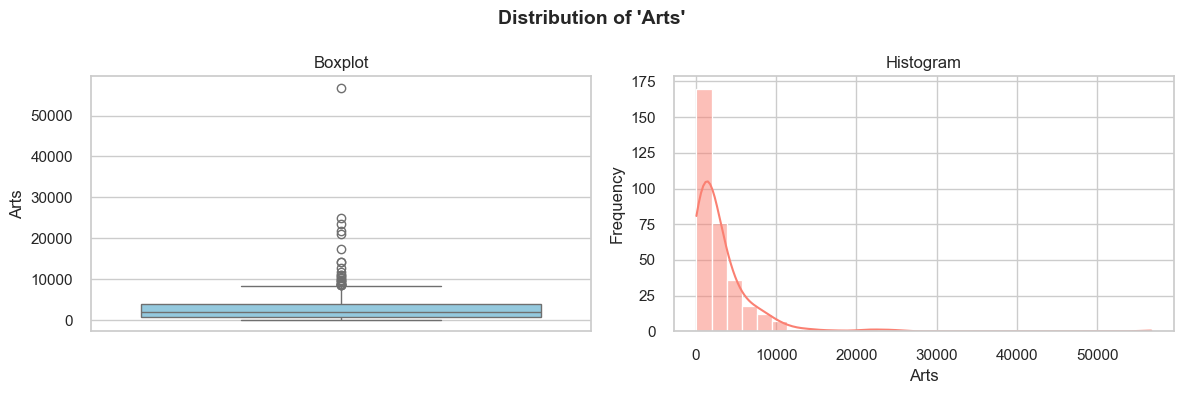

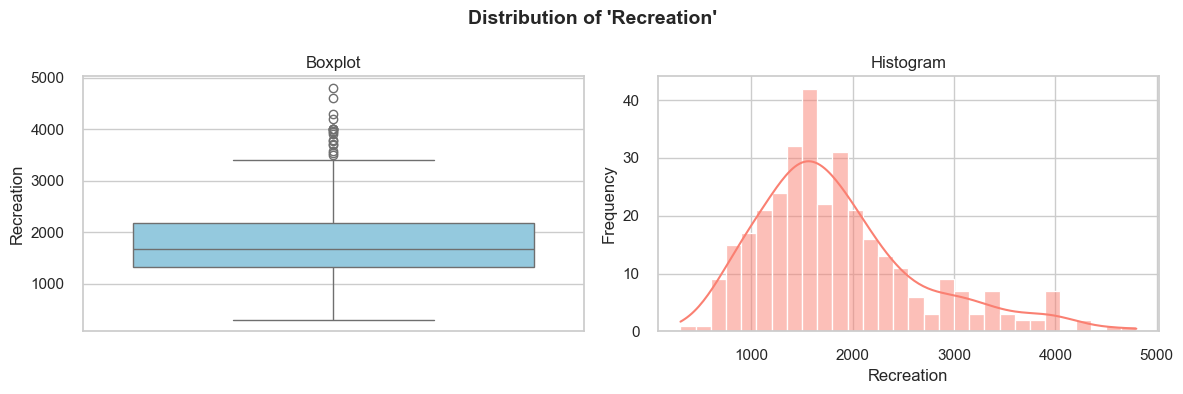

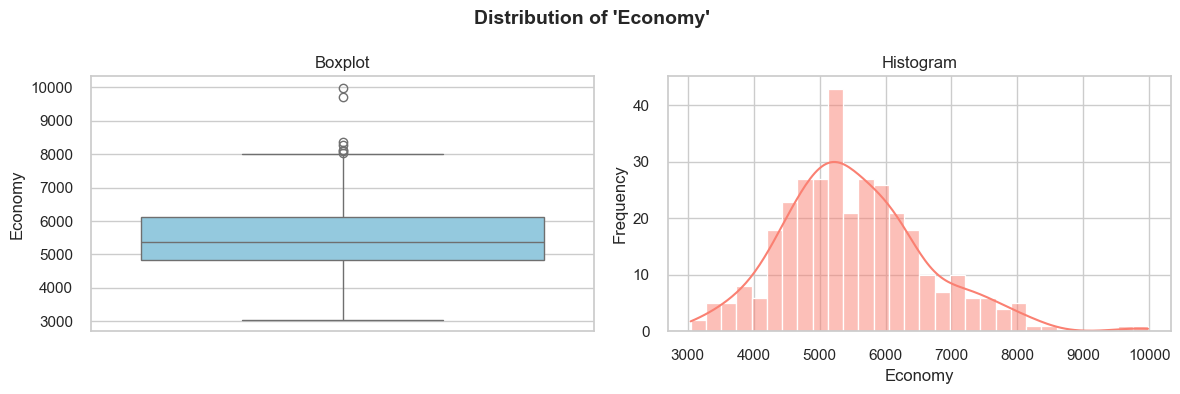

In [169]:
# Boxplot and histogram of variables
plot_numeric_distributions(df, cols=num_columns)

The univariate results indicate right-skewness in several variables, meaning many cities concentrate at lower-to-middle levels and fewer cities appear at very high levels.

Potential extreme observations are identified but preserved. Pedagogically, this is a valid decision when there is no domain-based justification for removal, especially in socioeconomic data where true heterogeneity is expected.


#### Multivariate Analysis





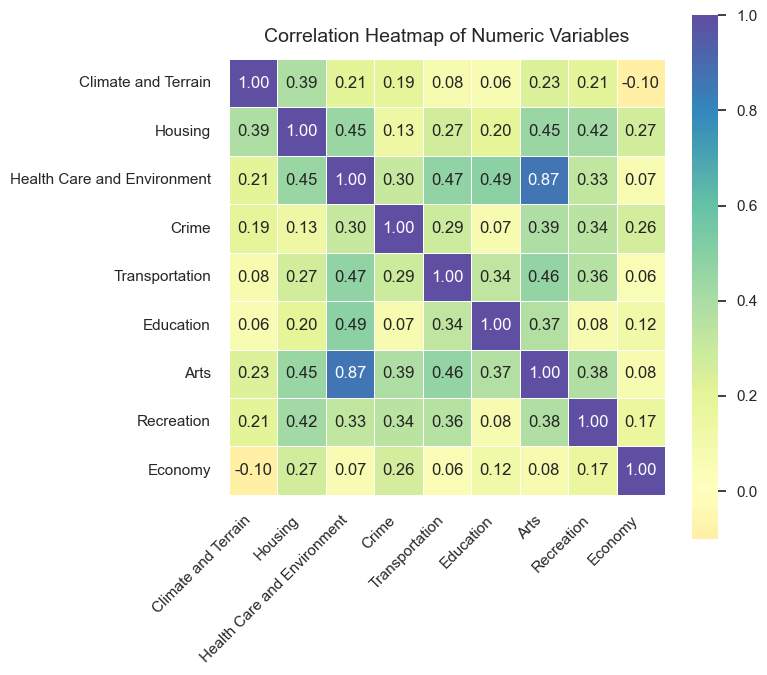

In [170]:
corr_matrix = df.corr()

# Set plot size
plt.figure(figsize=(8,8))

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Spectral", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})

# Visual adjustments
plt.title("Correlation Heatmap of Numeric Variables", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The correlation matrix shows one strong relationship (Health Care and Environment with Arts), while most other pairs are weak to moderate.

Interpretation: the dataset is not driven by a single common factor; instead, it reflects multiple partially related dimensions. This is precisely the type of structure where PCA is useful.


#### Variable Standardization





Variable direction is standardized conceptually before statistical standardization.

Because Housing and Crime are inversely interpreted, sign inversion ensures that component interpretation is coherent across variables. Without this step, positive loadings could mix "better" and "worse" meanings, making substantive conclusions confusing.


In [171]:
invert_columns = ["Housing", "Crime"]
df[invert_columns] = -df[invert_columns]

In [172]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Climate and Terrain,329.0,538.732523,120.808259,105.0,480.0,542.0,592.0,910.0
Housing,329.0,-8346.559271,2385.262622,-23640.0,-9015.0,-7877.0,-6760.0,-5159.0
Health Care and Environment,329.0,1185.738602,1003.002036,43.0,583.0,833.0,1445.0,7850.0
Crime,329.0,-961.054711,357.154186,-2498.0,-1156.0,-947.0,-707.0,-308.0
Transportation,329.0,4210.082067,1451.179240,1145.0,3141.0,4080.0,5205.0,8625.0
Education,329.0,2814.887538,320.792953,1701.0,2619.0,2794.0,3012.0,3781.0
Arts,329.0,3150.884498,4642.283738,52.0,778.0,1871.0,3844.0,56745.0
Recreation,329.0,1845.957447,807.888171,300.0,1316.0,1670.0,2176.0,4800.0
Economy,329.0,5525.364742,1084.468523,3045.0,4842.0,5384.0,6113.0,9980.0


In [173]:
X = df.copy()

Numeric standardization is applied before PCA because the method is variance-based.

If variables remain on different scales, those with larger magnitudes dominate the first components. Standardization (mean 0, standard deviation 1) gives each variable comparable influence and produces components that reflect structure rather than raw units.


In [174]:
# Scale data before PCA
scaler = StandardScaler()
X = scaler.fit_transform(df)
X = pd.DataFrame(X, columns = df.columns)
X.head()



,Climate and Terrain,Housing,Health Care and Environment,Crime,Transportation,Education,Arts,Recreation,Economy
0,-0.147006,0.901297,-0.947340,0.106712,-0.123592,-0.180726,-0.464893,-0.546646,1.946433
1,0.300664,0.087570,0.469568,0.210467,0.464411,-1.176652,0.520604,0.974442,-1.085467
2,-0.586386,0.423054,-0.566902,-0.025084,-1.158809,-0.795765,-0.628640,-1.223512,-0.254304
3,-0.520064,0.184142,0.244900,0.984419,1.844699,1.823613,0.324497,-0.283834,0.312735
4,0.997040,-0.019500,0.666278,-1.463626,1.620402,0.659098,0.290194,0.949648,0.186213


### 3. Calculation and Selection of Principal Components

This section implements PCA through linear algebra:
1. Compute covariance matrix of standardized data.
2. Perform eigen decomposition.
3. Rank components by explained variance.
4. Use scree/cumulative criteria to select retained components.

This sequence is correct and aligned with standard PCA workflow.


Conceptually:
- Eigenvectors define orthogonal directions of maximum variation.
- Eigenvalues quantify how much variance is captured in each direction.
- Principal components are projections of the original data onto those eigenvector directions.


##### Covariance Matrix





In [175]:
# Write your code here.
S = X.cov()
S

,Climate and Terrain,Housing,Health Care and Environment,Crime,Transportation,Education,Arts,Recreation,Economy
Climate and Terrain,1.003049,-0.387468,0.213953,-0.192974,0.079361,0.064716,0.227666,0.214160,-0.100388
Housing,-0.387468,1.003049,-0.454391,0.134631,-0.272751,-0.198537,-0.449935,-0.423576,-0.270254
Health Care and Environment,0.213953,-0.454391,1.003049,-0.305588,0.471751,0.491729,0.868436,0.326389,0.069482
Crime,-0.192974,0.134631,-0.305588,1.003049,-0.287452,-0.074643,-0.390670,-0.345677,-0.260787
Transportation,0.079361,-0.272751,0.471751,-0.287452,1.003049,0.337017,0.466223,0.365828,0.059427
Education,0.064716,-0.198537,0.491729,-0.074643,0.337017,1.003049,0.374417,0.078044,0.120065
Arts,0.227666,-0.449935,0.868436,-0.390670,0.466223,0.374417,1.003049,0.379814,0.075904
Recreation,0.214160,-0.423576,0.326389,-0.345677,0.365828,0.078044,0.379814,1.003049,0.174060
Economy,-0.100388,-0.270254,0.069482,-0.260787,0.059427,0.120065,0.075904,0.174060,1.003049


#### Eigenvalues and Eigenvectors





The notebook solves the eigenvalue equation `S v_i = lambda_i v_i`, where:
- `S` is the covariance matrix,
- `v_i` is the i-th principal direction,
- `lambda_i` is variance explained along that direction.


In [176]:
eig_val, eig_vec = np.linalg.eig(S)
eig_val

array([3.41868293, 1.21767731, 1.14495927, 0.9237255 , 0.75558148,
       0.63248434, 0.49455091, 0.31900812, 0.12076916])

Because there are 9 original variables, the decomposition returns 9 eigenvalues/eigenvectors. This one-to-one relationship is expected in PCA.


In [177]:
eig_vec

array([[ 2.06413954e-01, -2.17835308e-01,  6.89955982e-01,
        -1.37321246e-01, -3.69149929e-01, -3.74604694e-01,
         8.47057741e-02,  3.62308330e-01,  1.39135150e-03],
       [-3.56521608e-01,  2.50624000e-01, -2.08172230e-01,
         5.11828708e-01, -2.33487781e-01, -1.41639825e-01,
        -2.30638624e-01,  6.13855131e-01, -1.36003402e-02],
       [ 4.60214647e-01,  2.99465282e-01,  7.32492550e-03,
        -1.47018320e-02, -1.03240518e-01,  3.73848037e-01,
        -1.38676115e-02,  1.85676120e-01, -7.16354893e-01],
       [-2.81298380e-01,  3.55342273e-01,  1.85104981e-01,
        -5.39050473e-01,  5.23939687e-01,  8.09232850e-02,
         1.86064572e-02,  4.30024765e-01,  5.86084614e-02],
       [ 3.51150781e-01,  1.79604477e-01, -1.46376283e-01,
         3.02903705e-01,  4.04348475e-01, -4.67591803e-01,
         5.83390970e-01,  9.35986618e-02,  3.62945266e-03],
       [ 2.75292636e-01,  4.83382093e-01, -2.29702548e-01,
        -3.35411034e-01, -2.08819059e-01, -5.021698

Building `Lambda = diag(lambda)` is a useful pedagogical step because it separates direction (`V`) from magnitude (`Lambda`) in the decomposition.


In [178]:
eig_val_diag = np.diag(eig_val)
eig_val_diag

array([[3.41868293, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 1.21767731, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 1.14495927, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.9237255 , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.75558148,
        0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.63248434, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.49455091, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.31900812, 0.        ],


Reconstructing `S = V Lambda V^T` verifies that the decomposition is internally consistent and confirms that the covariance structure is fully represented by principal directions and their explained variances.


In [179]:
eig_vec.dot(eig_val_diag).dot(eig_vec.T)

array([[ 1.00304878, -0.38746841,  0.21395285, -0.19297385,  0.07936115,
         0.06471647,  0.22766619,  0.21415997, -0.10038787],
       [-0.38746841,  1.00304878, -0.45439081,  0.13463087, -0.27275053,
        -0.19853732, -0.44993535, -0.42357584, -0.27025421],
       [ 0.21395285, -0.45439081,  1.00304878, -0.30558826,  0.47175096,
         0.49172865,  0.86843566,  0.32638902,  0.06948193],
       [-0.19297385,  0.13463087, -0.30558826,  1.00304878, -0.28745214,
        -0.07464314, -0.39067005, -0.34567724, -0.26078738],
       [ 0.07936115, -0.27275053,  0.47175096, -0.28745214,  1.00304878,
         0.33701686,  0.46622266,  0.36582818,  0.05942738],
       [ 0.06471647, -0.19853732,  0.49172865, -0.07464314,  0.33701686,
         1.00304878,  0.37441703,  0.0780444 ,  0.12006529],
       [ 0.22766619, -0.44993535,  0.86843566, -0.39067005,  0.46622266,
         0.37441703,  1.00304878,  0.3798139 ,  0.07590401],
       [ 0.21415997, -0.42357584,  0.32638902, -0.34567724,  0

This expression can be interpreted as a weighted sum of orthogonal latent axes. The weight of each axis is its eigenvalue, so larger eigenvalues correspond to more informative components.


In [180]:
# Sort from largest to smallest
order = np.argsort(eig_val)[::-1]
eig_val = eig_val[order].real
eig_vec = eig_vec[:, order].real

Explained Variance





In [181]:
total = eig_val.sum()
total

np.float64(9.027439024390242)

In [182]:
explained_ratio = eig_val / total
explained_ratio

array([0.37869909, 0.13488624, 0.12683102, 0.1023242 , 0.08369832,
       0.07006243, 0.05478308, 0.03533761, 0.01337801])

In [183]:
cum_explained = explained_ratio.cumsum()
cum_explained

array([0.37869909, 0.51358533, 0.64041635, 0.74274055, 0.82643887,
       0.8965013 , 0.95128438, 0.98662199, 1.        ])

In [184]:
variance_table = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(eig_val))],
    "Eigenvalue": eig_val,
    "Variance (%)": explained_ratio*100,
    "Cumulative (%)": cum_explained*100
})
variance_table

,Component,Eigenvalue,Variance (%),Cumulative (%)
0,PC1,3.418683,37.869909,37.869909
1,PC2,1.217677,13.488624,51.358533
2,PC3,1.144959,12.683102,64.041635
3,PC4,0.923725,10.232420,74.274055
4,PC5,0.755581,8.369832,82.643887
5,PC6,0.632484,7.006243,89.650130
6,PC7,0.494551,5.478308,95.128438
7,PC8,0.319008,3.533761,98.662199
8,PC9,0.120769,1.337801,100.000000


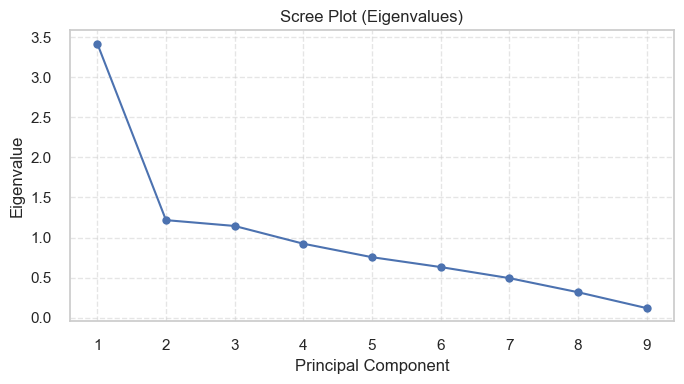

In [185]:
plt.figure(figsize=(7,4))
plt.plot(range(1, len(eig_val)+1), eig_val, marker='o')
plt.title("Scree Plot (Eigenvalues)")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.xticks(range(1, len(eig_val)+1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

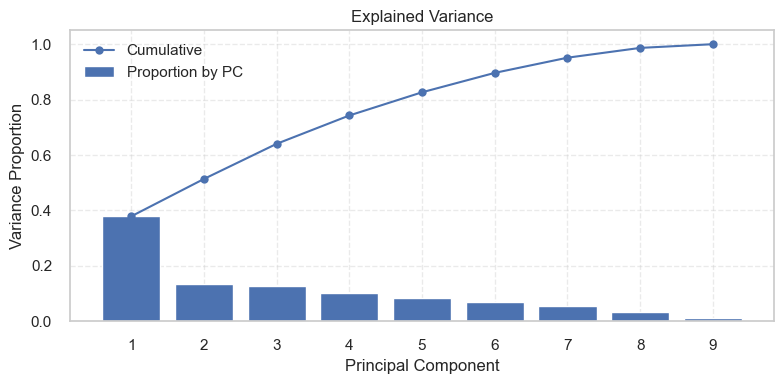

In [186]:
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(range(1, len(eig_val)+1), explained_ratio, label="Proportion by PC")
ax.plot(range(1, len(eig_val)+1), cum_explained, marker='o', label="Cumulative")
ax.set_xticks(range(1, len(eig_val)+1))
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Proportion")
ax.set_title("Explained Variance")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Explained-variance results are well interpreted:
- PC1 captures about **38%**,
- PC2 and PC3 each contribute around **13%**,
- marginal gain decreases after early components.

Retaining **5 components** (about **82.6%** cumulative variance) is a defensible choice under an information-retention criterion, balancing compression and interpretability.


### 4. Interpretation of Principal Components

After selecting dimensionality, this section moves from computation to interpretation by analyzing loadings, scores, and biplot geometry.


In [187]:
# Number of components to retain
m = 5

##### Weights/Loadings (variable-PC correlation) for the correlation matrix:





In [188]:
# L = V * sqrt(Lambda)
Lambda_sqrt = np.sqrt(eig_val)
L = eig_vec * Lambda_sqrt                  # column-wise broadcasting -> (n x n)
loadings = pd.DataFrame(L[:, :m], index=df.columns, columns=[f"PC{i+1}" for i in range(m)])
loadings

,PC1,PC2,PC3,PC4,PC5
Climate and Terrain,0.381653,-0.240378,0.738272,-0.131980,-0.320881
Housing,-0.659197,0.276560,-0.222750,0.491922,-0.202957
Health Care and Environment,0.850922,0.330455,0.007838,-0.014130,-0.089741
Crime,-0.520112,0.392115,0.198067,-0.518085,0.455430
Transportation,0.649267,0.198191,-0.156627,0.291123,0.351477
Education,0.509007,0.533404,-0.245788,-0.322366,-0.181514
Arts,0.856173,0.214948,0.028339,0.097149,-0.091355
Recreation,0.606254,-0.424262,0.054414,0.182419,0.460299
Economy,0.250373,-0.520054,-0.649843,-0.405366,-0.138748


Loadings are used correctly as interpretation weights: they indicate how strongly each original variable is associated with each component and help assign substantive meaning to latent axes.


In [189]:
def color_high(val):
    if val <-0.40:
        return 'background: pink'
    elif val >0.40:
        return 'background: skyblue'

loadings.style.map(color_high)

,PC1,PC2,PC3,PC4,PC5
Climate and Terrain,0.381653,-0.240378,0.738272,-0.131980,-0.320881
Housing,-0.659197,0.276560,-0.222750,0.491922,-0.202957
Health Care and Environment,0.850922,0.330455,0.007838,-0.014130,-0.089741
Crime,-0.520112,0.392115,0.198067,-0.518085,0.455430
Transportation,0.649267,0.198191,-0.156627,0.291123,0.351477
Education,0.509007,0.533404,-0.245788,-0.322366,-0.181514
Arts,0.856173,0.214948,0.028339,0.097149,-0.091355
Recreation,0.606254,-0.424262,0.054414,0.182419,0.460299
Economy,0.250373,-0.520054,-0.649843,-0.405366,-0.138748


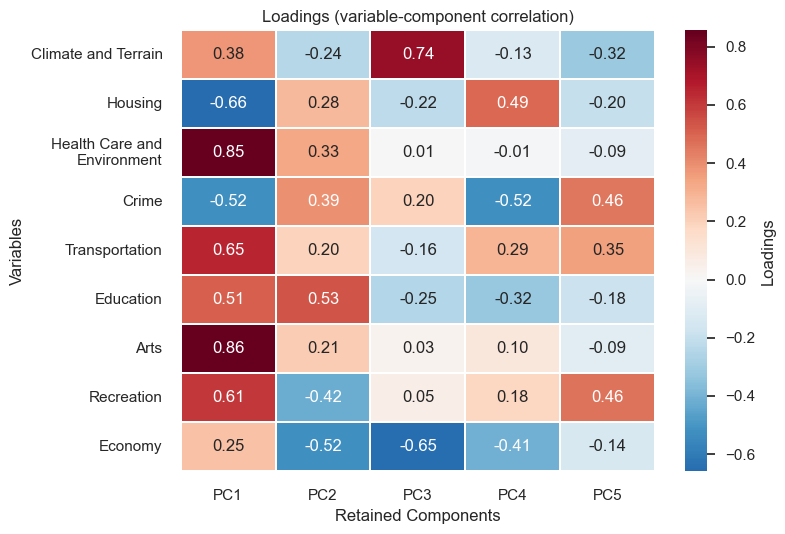

In [190]:
def wrap_labels(labels, max_words):
    wrapped_labels = []
    for label in labels:
        words = label.split()
        wrapped_label = '\n'.join([' '.join(words[i:i+max_words]) for i in range(0, len(words), max_words)])
        wrapped_labels.append(wrapped_label)
    return wrapped_labels

plt.figure(figsize = (8,5.5)) # Adjust figure size for readability
sns.heatmap(loadings, annot=True, fmt=".2f", center=0, cmap="RdBu_r", linewidths=0.3, cbar_kws={"label":"Loadings"})
plt.title("Loadings (variable-component correlation)")
plt.xlabel("Retained Components")
plt.ylabel("Variables")

# Get current Y-axis labels
current_labels = [item.get_text() for item in plt.gca().get_yticklabels()]

# Wrap labels
wrapped_labels = wrap_labels(current_labels, 3)

# Set wrapped labels back on Y-axis
plt.gca().set_yticklabels(wrapped_labels)

plt.tight_layout()
plt.show()

Component interpretation is coherent:
- **PC1** functions as a broad quality-of-life axis (strong Arts and Health Care/Environment contributions, plus relevant support from other aligned indicators).
- **PC2** captures a contrast pattern involving education versus economy/recreation profile.
- **PC3** emphasizes environmental-geographic structure (Climate and Terrain) with opposing tendency to economic intensity.

Important reminder for readers: Housing and Crime were sign-adjusted before PCA, so positive relationships should be interpreted in that aligned direction.


Compute Scores (Observation Coordinates)





In [191]:
# T = X V
T_np = X.dot(eig_vec)                       # (n x p) . (p x p)  -> (n x p)
T = pd.DataFrame(T_np, index=X.index)
T



,0,1,2,3,4,5,6,7,8
0,-1.041764,-0.895130,-1.438842,-0.510611,-0.565997,-0.498613,0.424397,1.003302,0.347934
1,0.440484,-0.075181,1.156475,1.113901,0.998402,0.629504,0.011913,0.419384,-0.121871
2,-1.878396,-0.069898,-0.073458,0.046302,-0.680559,0.715184,0.239859,-0.442570,-0.094344
3,0.912129,1.820351,-1.097817,-0.574454,0.770251,-1.273173,0.459415,0.372062,0.317760
4,2.152521,-0.329359,-0.019768,1.033073,-0.238913,-1.286180,0.154779,0.148490,-0.307621
...,...,...,...,...,...,...,...,...,...
324,-0.141198,1.644644,0.231229,-1.226067,-0.671732,-0.348644,-0.159297,-0.309478,-0.401114
325,-1.134349,-0.740957,0.319817,1.117127,0.099968,-0.027853,-0.258195,0.062597,0.145056
326,-1.710803,0.906311,0.658984,-1.342821,-0.312268,0.345408,-0.171137,-0.136948,0.166115
327,-0.766477,1.076964,0.963618,0.436489,-0.576634,-0.027105,-0.403765,-0.391342,0.057728


In [192]:
scores = T.iloc[:, :m]
scores.columns = [f"PC{i+1}" for i in range(m)]
scores.head()

,PC1,PC2,PC3,PC4,PC5
0,-1.041764,-0.895130,-1.438842,-0.510611,-0.565997
1,0.440484,-0.075181,1.156475,1.113901,0.998402
2,-1.878396,-0.069898,-0.073458,0.046302,-0.680559
3,0.912129,1.820351,-1.097817,-0.574454,0.770251
4,2.152521,-0.329359,-0.019768,1.033073,-0.238913


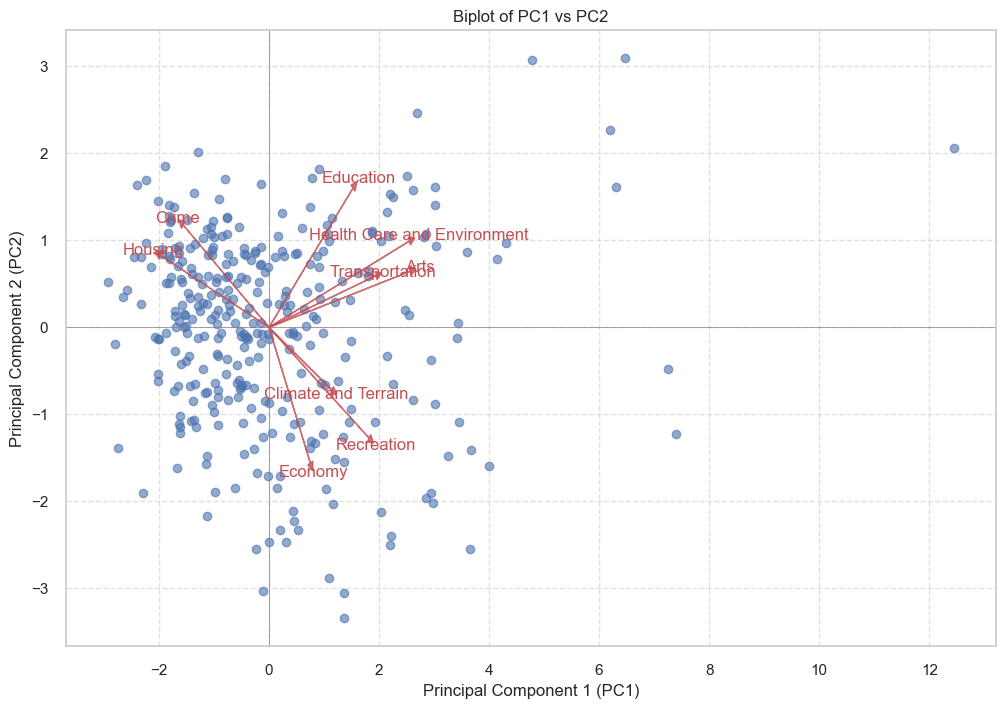

In [193]:
# Biplot of PC1 and PC2
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot of scores
ax.scatter(scores['PC1'], scores['PC2'], alpha=0.6)

# Add loading vectors
for i in range(loadings.shape[0]):
    ax.arrow(0, 0, loadings['PC1'].iloc[i]*3, loadings['PC2'].iloc[i]*3, color='r', alpha=0.8, head_width=0.1, head_length=0.1)
    ax.text(loadings['PC1'].iloc[i]*3.2, loadings['PC2'].iloc[i]*3.2, loadings.index[i], color='r', ha='center', va='center')

ax.set_xlabel("Principal Component 1 (PC1)")
ax.set_ylabel("Principal Component 2 (PC2)")
ax.set_title("Biplot of PC1 vs PC2")
ax.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.show()

The biplot explanation is methodologically correct:
- points = city scores in reduced space,
- arrows = variable directions and strengths,
- angle between arrows approximates correlation structure.

This is an effective way to connect algebraic PCA output to visual interpretation.


Interpreting PC1 vs PC2 is appropriate because these two axes summarize a large share of total variation.

Quadrant-based discussion is useful for communication, as long as it is treated as a descriptive aid rather than a strict clustering result. The notebook follows that intent.


### 5. Detection of Unusual Cities

This section defines atypical cities as observations with unusual **multivariate combinations** in retained component space, which is the correct framing for PCA-based outlier analysis.


##### Mahalanobis Distance

Mahalanobis distance is an appropriate metric here because it accounts for covariance structure among retained components. Unlike Euclidean distance, it measures distance in standardized multivariate geometry.


In [194]:
# Compute covariance matrix of scores
covariance_scores = scores.cov()

# Compute inverse covariance matrix
inv_covariance_scores = np.linalg.inv(covariance_scores)

# Compute mean of scores
mean_scores = scores.mean()

# Compute Mahalanobis distance for each city
mahalanobis_distances = []
for index, row in scores.iterrows():
    diff = row - mean_scores
    mahalanobis_distance = np.sqrt(diff.T @ inv_covariance_scores @ diff)
    mahalanobis_distances.append(mahalanobis_distance)

# Add Mahalanobis distances to scores DataFrame
scores['Mahalanobis_Distance'] = mahalanobis_distances

# Show cities with high Mahalanobis distance (possible outliers)
threshold = scores['Mahalanobis_Distance'].mean() + 2 * scores['Mahalanobis_Distance'].std()

unusual_cities = scores[scores['Mahalanobis_Distance'] > threshold].sort_values(by='Mahalanobis_Distance', ascending=False)

print("Cities with high Mahalanobis distance (possible outliers):")
print(unusual_cities)

print("\nIndexes of unusual cities:")
print(unusual_cities.index)

Cities with high Mahalanobis distance (possible outliers):
           PC1       PC2       PC3       PC4       PC5  Mahalanobis_Distance
212  12.445179  2.064887  0.210083  3.430722 -1.685713              8.083773
289   3.451349 -1.089921  1.659924 -4.247819  0.479805              5.167687
178   7.257344 -0.477878  2.054085  0.522492 -1.657330              4.817642
216   3.024101 -0.885666  1.297264 -3.718030  0.900282              4.563658
64    6.474759  3.091837 -0.392266  0.390757  0.514411              4.556670
269   7.402662 -1.228869  1.694329 -0.406496  0.755162              4.550876
132   2.857039 -1.961771  2.197414 -0.835117  2.252723              4.151733
226   0.309448 -2.472838  3.285906 -1.527875 -0.182721              4.129326
167   1.355981 -3.344152 -0.183106  2.323001  0.998686              4.112568
233   4.772628  3.077968 -0.340913 -0.368752 -1.243110              4.091089
88   -1.014824  1.222437 -0.919486  1.492086  3.016777              4.089252
313   6.195895  2

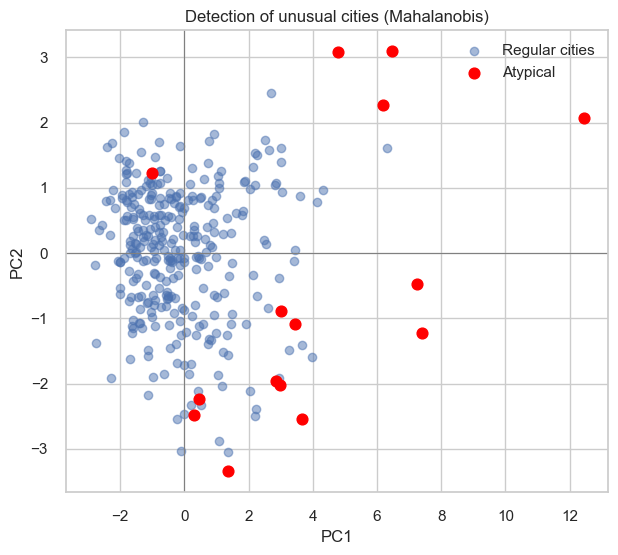

In [195]:
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(T.iloc[:,0], T.iloc[:,1], alpha=0.5, label="Regular cities")
ax.scatter(T.iloc[unusual_cities.index,0], T.iloc[unusual_cities.index,1], color="red", s=60, label="Atypical")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Detection of unusual cities (Mahalanobis)")
ax.legend()
plt.show()

##### Chi-Square





Using squared Mahalanobis distance with a Chi-square cutoff provides a principled decision rule.

Under approximate multivariate normality of scores, `D^2 ~ Chi-square(k)`, where `k` is the number of retained components. This converts distance values into a statistically interpretable threshold.


In [196]:
mahalanobis_sq = []
for index, row in scores.iterrows():
    diff = row[['PC1','PC2','PC3','PC4','PC5']] - mean_scores
    m_sq = diff.T @ inv_covariance_scores @ diff
    mahalanobis_sq.append(m_sq)

scores['Mahalanobis_Sq'] = mahalanobis_sq
alpha = 0.01  # for example, 99% confidence
threshold_chi2 = chi2.ppf(1 - alpha, df=5)
print("Chi-square threshold with alpha=0.01 and df=5:", threshold_chi2)
unusual_cities_chi2 = scores[scores['Mahalanobis_Sq'] > threshold_chi2].copy()
unusual_cities_chi2 = unusual_cities_chi2.sort_values(by='Mahalanobis_Sq', ascending=False)

print("Unusual cities according to chi-square:")
print(unusual_cities_chi2[['PC1','PC2','PC3','PC4','PC5','Mahalanobis_Sq']])

print("\nIndexes of unusual cities:")
print(unusual_cities_chi2.index)

Chi-square threshold with alpha=0.01 and df=5: 15.086272469388987
Unusual cities according to chi-square:
           PC1       PC2       PC3       PC4       PC5  Mahalanobis_Sq
212  12.445179  2.064887  0.210083  3.430722 -1.685713       65.347392
289   3.451349 -1.089921  1.659924 -4.247819  0.479805       26.704990
178   7.257344 -0.477878  2.054085  0.522492 -1.657330       23.209671
216   3.024101 -0.885666  1.297264 -3.718030  0.900282       20.826972
64    6.474759  3.091837 -0.392266  0.390757  0.514411       20.763239
269   7.402662 -1.228869  1.694329 -0.406496  0.755162       20.710476
132   2.857039 -1.961771  2.197414 -0.835117  2.252723       17.236890
226   0.309448 -2.472838  3.285906 -1.527875 -0.182721       17.051335
167   1.355981 -3.344152 -0.183106  2.323001  0.998686       16.913215
233   4.772628  3.077968 -0.340913 -0.368752 -1.243110       16.737011
88   -1.014824  1.222437 -0.919486  1.492086  3.016777       16.721982
313   6.195895  2.268324 -0.376075 -0.6578

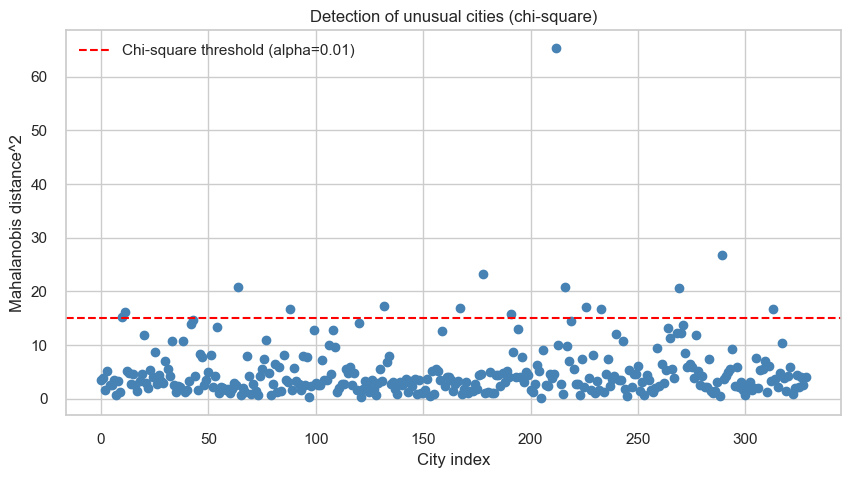

In [197]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(range(len(scores)), scores['Mahalanobis_Sq'], color='steelblue')
plt.axhline(y=threshold_chi2, color='red', linestyle='--', label=f'Chi-square threshold (alpha={alpha})')
plt.xlabel('City index')
plt.ylabel('Mahalanobis distance^2')
plt.title('Detection of unusual cities (chi-square)')
plt.legend()
plt.show()

##### Conclusions





In this analysis, an atypical city is one whose joint profile across socioeconomic and environmental indicators differs substantially from the dominant multivariate pattern.

This should be interpreted as structural distinctiveness, not automatically as data error.


In [198]:
data.iloc[unusual_cities.index]

,Climate and Terrain,Housing,Health Care and Environment,Crime,Transportation,Education,Arts,Recreation,Economy
City,,,,,,,,,
"New-York,NY",638,13358,7850,2498,8625,2984,56745,3579,5338
"Stamford,CT",648,23640,2610,835,3110,3029,7865,1729,6158
"Los-Angeles,Long-Beach,CA",885,13868,5153,1960,4345,3195,23567,3948,5316
"Norwalk,CT",648,20151,2530,625,3536,3029,7273,2268,6432
"Chicago,IL",514,10913,5766,1034,7742,3486,24846,2856,5205
"San-Francisco,CA",910,17158,3726,1619,8299,3371,14226,4600,6063
"Honolulu,HI",717,17021,1298,891,5911,2502,7168,3703,5187
"Oxnard-Ventura,CA",890,14000,1106,791,2238,2155,2769,2135,5514
"Las-Vegas,NV",556,9906,412,1913,5900,2241,1586,3996,6035


In [199]:
unusual_data = data.iloc[unusual_cities.index]
unusual_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Climate and Terrain,15.0,638.266667,220.785761,193.0,593.0,638.0,801.0,910.0
Housing,15.0,13771.866667,4575.346402,6040.0,10590.0,13724.0,16534.0,23640.0
Health Care and Environment,15.0,3071.266667,2185.820031,412.0,1228.5,2530.0,4757.0,7850.0
Crime,15.0,1313.000000,637.079273,488.0,863.0,1059.0,1766.0,2498.0
Transportation,15.0,5553.133333,1979.151328,2238.0,4149.5,5205.0,6826.5,8625.0
Education,15.0,2944.200000,496.145025,2155.0,2560.5,2984.0,3283.0,3781.0
Arts,15.0,13347.200000,14478.207669,1586.0,3803.0,7273.0,19485.5,56745.0
Recreation,15.0,3062.266667,961.120958,1578.0,2201.5,3107.0,3825.5,4600.0
Economy,15.0,5773.866667,810.448012,3922.0,5327.0,5840.0,6115.0,7668.0


In [200]:
regular_data = data.iloc[~data.index.isin(unusual_cities.index)]
regular_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Climate and Terrain,329.0,538.732523,120.808259,105.0,480.0,542.0,592.0,910.0
Housing,329.0,8346.559271,2385.262622,5159.0,6760.0,7877.0,9015.0,23640.0
Health Care and Environment,329.0,1185.738602,1003.002036,43.0,583.0,833.0,1445.0,7850.0
Crime,329.0,961.054711,357.154186,308.0,707.0,947.0,1156.0,2498.0
Transportation,329.0,4210.082067,1451.179240,1145.0,3141.0,4080.0,5205.0,8625.0
Education,329.0,2814.887538,320.792953,1701.0,2619.0,2794.0,3012.0,3781.0
Arts,329.0,3150.884498,4642.283738,52.0,778.0,1871.0,3844.0,56745.0
Recreation,329.0,1845.957447,807.888171,300.0,1316.0,1670.0,2176.0,4800.0
Economy,329.0,5525.364742,1084.468523,3045.0,4842.0,5384.0,6113.0,9980.0


Observed atypical-city patterns are explained clearly:
- higher Health Care and Environment levels,
- stronger Arts values,
- higher Recreation tendency.

Educationally, the key idea is that atypicality emerges from a **combination** of features, not from one isolated extreme variable.


### 6. Robustness of Results: Standardizing the Data

This final section tests robustness by comparing PCA behavior with and without standardization, which is an important methodological validation step.


In [201]:
def pca_fit(data):
    pca = PCA()
    pca.fit(data)
    evr = pca.explained_variance_ratio_
    cev = np.cumsum(evr)
    eig = pca.explained_variance_
    return evr, cev, eig

def n_components_for_threshold(cum_vec, thr):
    return int(np.searchsorted(cum_vec, thr) + 1)

In [202]:
# --- PCA on original and standardized data ---
evr_df, cev_df, eig_df = pca_fit(df)
evr_X,  cev_X,  eig_X  = pca_fit(X)  # X is already standardized

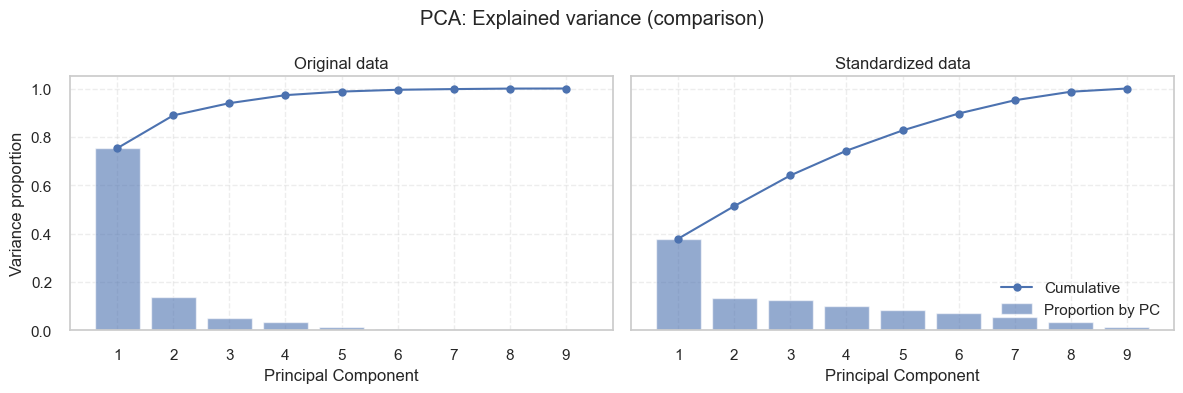

In [203]:
# --- Comparative plots (explained variance) ---
k = len(evr_df)
xs = np.arange(1, k+1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, evr, cev, title in [
    (axes[0], evr_df, cev_df, "Original data"),
    (axes[1], evr_X,  cev_X,  "Standardized data")
]:
    ax.bar(xs, evr, alpha=0.6, label="Proportion by PC")
    ax.plot(xs, cev, marker="o", label="Cumulative")
    ax.set_xticks(xs)
    ax.set_xlabel("Principal Component")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.35)
axes[0].set_ylabel("Variance proportion")
axes[1].legend(loc="lower right")
plt.suptitle("PCA: Explained variance (comparison)")
plt.tight_layout()
plt.show()

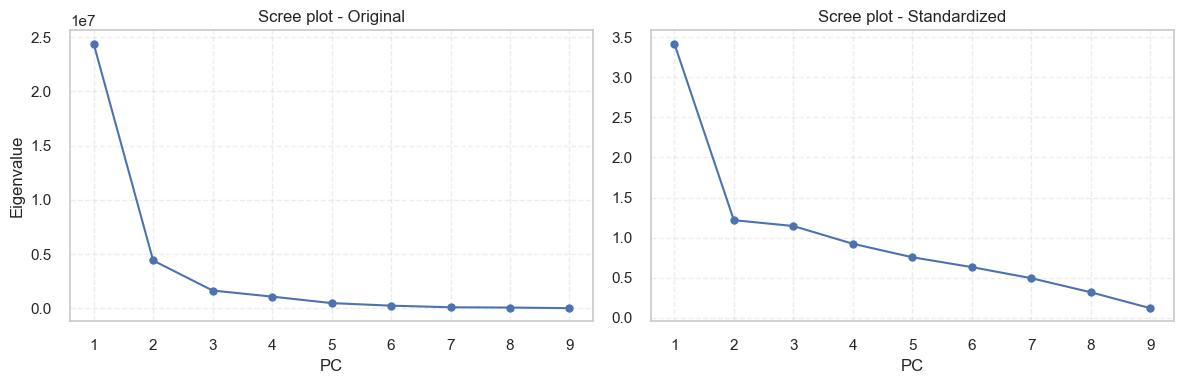

In [204]:
# --- Optional scree plots of eigenvalues for both ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(xs, eig_df, marker='o'); ax[0].set_title("Scree plot - Original")
ax[0].set_xlabel("PC"); ax[0].set_ylabel("Eigenvalue"); ax[0].grid(True, ls="--", alpha=0.35)
ax[1].plot(xs, eig_X, marker='o');  ax[1].set_title("Scree plot - Standardized")
ax[1].set_xlabel("PC"); ax[1].grid(True, ls="--", alpha=0.35)
plt.tight_layout(); plt.show()

In [205]:
# --- Key metrics and automated conclusions ---
thr80_df = n_components_for_threshold(cev_df, 0.80)
thr90_df = n_components_for_threshold(cev_df, 0.90)
thr80_X  = n_components_for_threshold(cev_X,  0.80)
thr90_X  = n_components_for_threshold(cev_X,  0.90)

# Kaiser criterion only makes sense on standardized data (correlation-based)
# Keep a component if its eigenvalue lambda > 1
# This applies when variables are standardized (mean 0, std 1)
kaiser_X = (eig_X > 1).sum()

summary = pd.DataFrame({
    "Scenario": ["Original", "Standardized"],
    "PC1 % var": [evr_df[0]*100, evr_X[0]*100],
    "PCs for >=80%": [thr80_df, thr80_X],
    "PCs for >=90%": [thr90_df, thr90_X],
    "Kaiser (λ>1)": ["—", kaiser_X]
}).round(2)

print("Comparative PCA summary\n")
print(summary.to_string(index=False))

Comparative PCA summary

    Scenario  PC1 % var  PCs for >=80%  PCs for >=90% Kaiser (λ>1)
    Original      75.29              2              3            —
Standardized      37.87              5              7            3


In [206]:
# --- Conclusion text using your results ---
print("\nConclusions:\n")
print(f"- In ORIGINAL data: PC1 explains {evr_df[0]*100:.2f}% and with {thr80_df} PCs you exceed 80% "
      f"(with {thr90_df} PCs you exceed 90%).\nVariance is HIGHLY concentrated in PC1 -> "
      f"driven by large-scale variables.")
print(f"\n- In STANDARDIZED data: PC1 explains {evr_X[0]*100:.2f}%, and {thr80_X} PCs are needed for >=80% "
      f"and {thr90_X} PCs for >=90%.\nContributions are more balanced across PCs.")
print(f"\n- Kaiser criterion (lambda > 1) on standardized data suggests retaining {kaiser_X} components.")
print("\n- Interpretation: standardization removes scale bias.\nComponents change their "
      "relative importance and information is spread across more PCs,\nwhile keeping coherent interpretations "
      "(axes represent correlations, not absolute variances).")



Conclusions:

- In ORIGINAL data: PC1 explains 75.29% and with 2 PCs you exceed 80% (with 3 PCs you exceed 90%).
Variance is HIGHLY concentrated in PC1 -> driven by large-scale variables.

- In STANDARDIZED data: PC1 explains 37.87%, and 5 PCs are needed for >=80% and 7 PCs for >=90%.
Contributions are more balanced across PCs.

- Kaiser criterion (lambda > 1) on standardized data suggests retaining 3 components.

- Interpretation: standardization removes scale bias.
Components change their relative importance and information is spread across more PCs,
while keeping coherent interpretations (axes represent correlations, not absolute variances).


The comparison is correctly interpreted:
- Without standardization, variance concentrates heavily in PC1 (scale dominance).
- With standardization, variance is distributed more evenly, producing a more balanced component structure.

Final teaching point: standardization changes the geometry of PCA from unit-driven variance to relative-pattern variance, which usually improves interpretability in mixed-scale datasets.
